In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
dfwindTrain = pd.read_csv('../data/wd_train.csv')
dfwindVal = pd.read_csv('../data/wd_val.csv')
dfwindTest = pd.read_csv('../data/wd_test.csv')

In [ ]:
dfwindVal

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wind direction
0,994.77,6.07,279.64,2.92,80.20,9.40,7.54,1.86,4.73,7.58,1237.52,0.74,1.68,O
1,994.54,9.88,283.48,4.18,67.58,12.20,8.24,3.95,5.17,8.29,1220.23,0.58,1.12,O
2,994.35,13.53,287.15,5.79,59.42,15.53,9.23,6.30,5.79,9.28,1204.01,0.70,1.46,S
3,994.04,15.43,289.08,6.84,56.50,17.56,9.92,7.64,6.23,9.98,1195.39,0.92,1.84,S
4,993.88,15.54,289.21,7.58,59.02,17.68,10.44,7.25,6.56,10.50,1194.50,0.30,0.56,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,978.85,20.27,295.23,12.82,62.26,23.81,14.83,8.99,9.48,15.15,1155.44,3.64,5.22,S
4996,978.52,20.33,295.32,13.71,65.71,23.90,15.71,8.20,10.04,16.05,1154.41,3.45,5.20,S
4997,978.84,20.27,295.23,13.11,63.45,23.81,15.11,8.70,9.66,15.44,1155.30,4.50,6.20,S
4998,978.98,21.29,296.24,13.19,59.90,25.36,15.19,10.17,9.71,15.51,1151.43,4.16,6.81,S


In [ ]:
dfwindTrain.cc =  pd.Categorical(dfwindTrain['wind direction'])

/var/folders/3v/ht1smwlj4ss7xvh6f257wwrw0000gn/T/ipykernel_47427/2328101472.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dfwindTrain.cc =  pd.Categorical(dfwindTrain['wind direction'])


In [ ]:
dfwindTrain['wind direction'] = dfwindTrain.cc.codes
dfwindTrain['wind direction']

0        3
1        3
2        3
3        0
4        3
        ..
59995    3
59996    0
59997    2
59998    3
59999    3
Name: wind direction, Length: 60000, dtype: int8

In [ ]:
windtrain = dfwindTrain.values

In [ ]:
windtrain

array([[ 9.9650e+02, -8.0500e+00,  2.6538e+02, ...,  2.1000e-01,
         6.3000e-01,  3.0000e+00],
       [ 9.9662e+02, -8.8800e+00,  2.6454e+02, ...,  2.5000e-01,
         6.3000e-01,  3.0000e+00],
       [ 9.9684e+02, -8.8100e+00,  2.6459e+02, ...,  1.8000e-01,
         6.3000e-01,  3.0000e+00],
       ...,
       [ 9.9462e+02,  2.0200e+00,  2.7561e+02, ...,  2.2000e-01,
         5.4000e-01,  2.0000e+00],
       [ 9.9504e+02,  2.2700e+00,  2.7582e+02, ...,  7.5000e-01,
         1.0200e+00,  3.0000e+00],
       [ 9.9491e+02,  4.7100e+00,  2.7828e+02, ...,  4.5000e-01,
         1.4400e+00,  3.0000e+00]], shape=(60000, 14))

# Exercise 1:

Using the above datasets (train, validation and test), train a ***recurrent*** neural network to predict the wind direction for each of the next 6 hours using all the weather data from the last 3 days(72 hours).

## Create training data for the recurrent neural network in same way we did when using feedforward and convolutional neural networks to predict the temperature.

In [ ]:
windtrainTargets = windtrain[:,-1]
windtrainTargets.shape

(60000,)

In [ ]:
windtrainTargets[72:78]

array([0., 3., 2., 3., 3., 3.])

## Creating the target sequences:
### Each timestep is length-6 sequence
### The first sequence starts at the hour 72 and ends at the hour 77. The second starts at the hour 73 and ends at the hour 78, and so on..
### There 60000-72-5 target sequences

In [ ]:
nSeqs = 60000-72-5
traintargetseqs = np.zeros((nSeqs,6))
for i in range(nSeqs):
    traintargetseqs[i] = windtrainTargets[72+i:72+i+6]

In [ ]:
traintargetseqs[0]

array([0., 3., 2., 3., 3., 3.])

In [ ]:
traintargetseqs.shape

(59923, 6)

In [ ]:
tf.get_logger().setLevel('ERROR')
tdata = windtrain[:-6]
sequence_length = 72
batch_size=32

trainDset = tf.keras.utils.timeseries_dataset_from_array(
    data=windtrain,
    targets=traintargetseqs,
    sequence_length= sequence_length,
    batch_size=batch_size,
    shuffle=True)


it = iter(trainDset)
ex = next(it)
print(ex[0].shape, ex[1].shape)

(32, 72, 14) (32, 6)


### Creating also validation and test data in the same way we did for the training data

In [ ]:
print(dfwindVal.shape)
print(dfwindTest.shape)

(5000, 14)
(5091, 14)


In [ ]:
# Validation
dfwindVal.cc =  pd.Categorical(dfwindVal['wind direction'])
dfwindVal['wind direction'] = dfwindVal.cc.codes
windval = dfwindVal.values
windvalTargets = windval[:,-1]
# validation target sequences
nValSeqs = 5000-72-5
valtargetseqs = np.zeros((nValSeqs,6))
for i in range(nValSeqs):
    valtargetseqs[i] = windvalTargets[72+i:72+i+6]
valDset = tf.keras.utils.timeseries_dataset_from_array(
    data=windval,
    targets=valtargetseqs,
    sequence_length= sequence_length,
    batch_size=128,
    shuffle=False)

/var/folders/3v/ht1smwlj4ss7xvh6f257wwrw0000gn/T/ipykernel_47427/3922156638.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dfwindVal.cc =  pd.Categorical(dfwindVal['wind direction'])


In [ ]:
# Test
dfwindTest.cc =  pd.Categorical(dfwindTest['wind direction'])
dfwindTest['wind direction'] = dfwindTest.cc.codes
windtest = dfwindTest.values
windtestTargets = windtest[:,-1]
# test target sequences
nTestSeqs = 5091-72-5
testtargetseqs = np.zeros((nTestSeqs,6))
for i in range(nTestSeqs):
    testtargetseqs[i] = windtestTargets[72+i:72+i+6]
testDset = tf.keras.utils.timeseries_dataset_from_array(
    data=windtest,
    targets=testtargetseqs,
    sequence_length= sequence_length,
    batch_size=128,
    shuffle=False)

/var/folders/3v/ht1smwlj4ss7xvh6f257wwrw0000gn/T/ipykernel_47427/1419798168.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dfwindTest.cc =  pd.Categorical(dfwindTest['wind direction'])


## Defining the recurrent neural network model

In [ ]:
from tensorflow import keras
from keras import layers, models
from keras.layers import Input,GRU, Dense, Reshape

In [ ]:
model = models.Sequential()
model.add(Input(shape=(72,14)))
model.add(GRU(50, return_sequences=True))
model.add(GRU(50))
model.add(Dense(24))
model.add(Reshape((6,4)))
model.add(layers.Softmax(axis=-1))

In [ ]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=keras.optimizers.Adam(0.0001), metrics=[ keras.metrics.SparseCategoricalAccuracy()])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 72, 50)         │         9,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 6, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 6, 4)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,424 (103.22 KB)

 Trainable params: 26,424 (103.22 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit network
history = model.fit(trainDset,epochs=10, validation_data=(valDset))

Epoch 1/10
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 1.2539 - sparse_categorical_accuracy: 0.4375 - val_loss: 1.1698 - val_sparse_categorical_accuracy: 0.5053
Epoch 2/10
 280/1873 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 1.2308 - sparse_categorical_accuracy: 0.4533

KeyboardInterrupt: 

In [ ]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

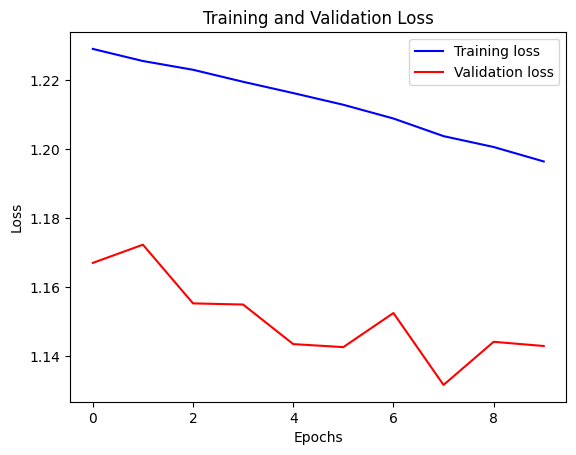

In [ ]:
htloss = history.history['loss']
hvloss = history.history['val_loss']

epochs = range(len(htloss))
plt.figure()
plt.plot(epochs, htloss, "b", label="Training loss")
plt.plot(epochs, hvloss, "r", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

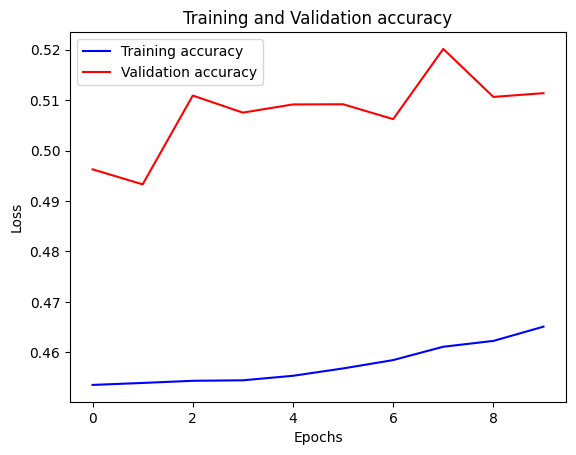

In [ ]:
htaccu = history.history['sparse_categorical_accuracy']
hvaccu = history.history['val_sparse_categorical_accuracy']

epochs = range(len(htloss))
plt.figure()
plt.plot(epochs, htaccu, "b", label="Training accuracy")
plt.plot(epochs, hvaccu, "r", label="Validation accuracy")
plt.title("Training and Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()